Donations & Campaign Performance Analysis for NGO ************

Context:

    NGO wants to increase donations and campaign effectiveness
    raw data → requires preparation and analysis

Business goals:

    increase retention
    find the most effective channels
    optimize campaign costs

KEY QUESTIONS:
    
    1. Which channels bring in the most valuable donors?
    2. What is the donor retention rate?
    3. Which campaigns have the best ROI?
    4. How do donations convert into real impact?
    5. Who are our high-value donors?

In [127]:
#---------
#DATA LOAD
#---------

In [128]:
import pandas as pd

In [129]:
donors=pd.read_csv('donors_raw.csv')
donations=pd.read_csv('donations_raw.csv')
campaigns=pd.read_csv('campaigns_raw.csv')
impact=pd.read_csv('impact_raw.csv')

In [130]:
print(donors.shape)
print(donations.shape)
print(campaigns.shape)
print(impact.shape)

(520, 4)
(2000, 4)
(20, 4)
(20, 3)


In [131]:
print(donors.head())
print(donations.head())
print(campaigns.head())
print(impact.head())

   donor_id   age  country acquisition_channel
0         1  56.0       UK               Email
1         2  69.0  Ukraine            Referral
2         3  46.0   Poland            Referral
3         4  32.0   Poland          Google Ads
4         5  60.0  Ukraine             Organic
   donor_id  campaign_id        date amount
0       390           20  2024-12-30    167
1       314           17  2024-07-09    498
2        22            3  2024-08-12    349
3       410            5  2024-12-28    396
4        71           19  2024-09-01    349
   campaign_id       type  cost  start_date
0            1  Emergency  9619  2023-01-01
1            2  Emergency  2895  2023-01-16
2            3  Education  7090  2023-01-31
3            4  Emergency  9508  2023-02-15
4            5  Emergency  7082  2023-03-02
   campaign_id  people_helped  category
0            1            645      Food
1            2           1028  Refugees
2            3            780  Children
3            4            106 

In [132]:
#---------
#DATA CLEANING
#---------

In [133]:
#CLEAN donors

In [134]:
donors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   donor_id             520 non-null    int64  
 1   age                  510 non-null    float64
 2   country              460 non-null    object 
 3   acquisition_channel  418 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 16.4+ KB


In [135]:
duplicates_donors=donors.duplicated().sum()
print('Duplicates:', duplicates_donors)

Duplicates: 20


In [136]:
donors=donors.drop_duplicates()

In [137]:
missing_donors=donors.isna().sum().sort_values(ascending=False)
print(missing_donors)

acquisition_channel    97
country                60
age                    10
donor_id                0
dtype: int64


In [138]:
donors['acquisition_channel']=donors['acquisition_channel'].fillna('Unknown')

age_donors=donors['age'].astype(float).median()
donors['age']=donors['age'].fillna(age_donors)

In [139]:
donors['country'].unique()

array(['UK', 'Ukraine', 'Poland', 'ukraine', nan, 'Germany', 'USA'],
      dtype=object)

In [140]:
donors['country']=donors['country'].str.lower().str.strip()

country_donors=donors['country'].value_counts().idxmax()
donors['country']=donors['country'].fillna(country_donors)

In [141]:
#CLEAN donations

In [142]:
donations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   donor_id     2000 non-null   int64 
 1   campaign_id  2000 non-null   int64 
 2   date         2000 non-null   object
 3   amount       1979 non-null   object
dtypes: int64(2), object(2)
memory usage: 62.6+ KB


In [143]:
duplicates_donations=donations.duplicated().sum()
print('Duplicates:', duplicates_donations)

Duplicates: 0


In [144]:
missing_donations=donations.isna().sum().sort_values(ascending=False)
print(missing_donations)

amount         21
donor_id        0
campaign_id     0
date            0
dtype: int64


In [145]:
donations['amount']=pd.to_numeric(donations['amount'], errors='coerce')

donations=donations[donations['amount']>0]
donations=donations.dropna(subset=['amount'])

donations['date']=pd.to_datetime(donations['date'])

In [146]:
#CLEAN campaigns

In [147]:
campaigns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   campaign_id  20 non-null     int64 
 1   type         20 non-null     object
 2   cost         20 non-null     int64 
 3   start_date   20 non-null     object
dtypes: int64(2), object(2)
memory usage: 772.0+ bytes


In [148]:
duplicates_campaigns=campaigns.duplicated().sum()
print('Duplicates:', duplicates_campaigns)

Duplicates: 0


In [149]:
missing_campaigns=campaigns.isna().sum().sort_values(ascending=False)
print(missing_campaigns)

campaign_id    0
type           0
cost           0
start_date     0
dtype: int64


In [150]:
#CLEAN impact

In [151]:
impact.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   campaign_id    20 non-null     int64 
 1   people_helped  20 non-null     int64 
 2   category       20 non-null     object
dtypes: int64(2), object(1)
memory usage: 612.0+ bytes


In [152]:
duplicates_impact=impact.duplicated().sum()
print('Duplicates:', duplicates_impact)

Duplicates: 0


In [153]:
missing_impact=impact.isna().sum().sort_values(ascending=False)
print(missing_impact)

campaign_id      0
people_helped    0
category         0
dtype: int64


In [154]:
#Negative donations and invalid values were removed to ensure realistic revenue calculations

In [155]:
#Data Merge

df=donations.merge(donors, on='donor_id', how='left') \
            .merge(campaigns, on='campaign_id', how='left') \
            .merge(impact, on='campaign_id', how='left')

df.head()

,donor_id,campaign_id,date,amount,age,country,acquisition_channel,type,cost,start_date,people_helped,category
0,390,20,2024-12-30,167.0,54.0,poland,Unknown,Health,1899,2023-10-13,958,Food
1,314,17,2024-07-09,498.0,20.0,usa,Referral,Health,3430,2023-08-29,2343,Children
2,22,3,2024-08-12,349.0,41.0,usa,Email,Education,7090,2023-01-31,780,Children
3,410,5,2024-12-28,396.0,57.0,poland,Organic,Emergency,7082,2023-03-02,2293,Refugees
4,71,19,2024-09-01,349.0,57.0,usa,Facebook Ads,Education,1207,2023-09-28,711,Food


In [156]:
#FEATURE ENGINEERING
    #revenue per donor
donor_revenue=df.groupby('donor_id')['amount'].sum()

    #donations count
donor_freq=df.groupby('donor_id')['amount'].count().reset_index()
donor_freq.columns = ['donor_id', 'frequency']

    #LTV
df['ltv']=df.groupby('donor_id')['amount'].transform('sum')

    #ROI
df['roi']=df['amount']/df['cost']

    #impact efficiency
df['cost_per_person']=df['cost']/df['people_helped']

In [157]:
#---------
#EDA
#---------

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import datetime as dt

In [159]:
#Revenue Trend

In [160]:
rev_trend = df.groupby(df['date'].dt.to_period('M'))['amount'].sum()
rev_trend = rev_trend.reset_index()
rev_trend['date'] = rev_trend['date'].astype(str) 

fig = px.line(rev_trend, x='date', y='amount', title='Revenue Trend')
fig.show()

Revenues show sharp fluctuations from 16,000 to 27,000, with each peak (e.g., in August 2023 and January 2024) followed by a negative decline to a minimum value. This means that as an NGO ************ you are heavily dependent on large one-time contributions or ad hoc commissions, but have a low proportion of regular payments that would create a stable “financial cushion.” This is important because such instability makes it impossible to launch long-term social programs, since you cannot accurately predict what budget you will have in 2-3 months.


In [161]:
#Chanel Perfomance

In [162]:
chanel_perf1=df.groupby('acquisition_channel')['amount'].mean().sort_values().reset_index()
chanel_perf2=df.groupby('acquisition_channel')['donor_id'].nunique().reset_index()

fig=make_subplots(rows=1, cols=2)
fig.add_trace(
    go.Bar(x=chanel_perf1['acquisition_channel'], y=chanel_perf1['amount'], name='Quality Chanel Perf'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=chanel_perf2['acquisition_channel'], y=chanel_perf2['donor_id'], name='Volume Chanel Perf'),
    row=1, col=2
)

fig.update_layout(height=500, width=1000, title_text='Chanel Perfomance')
fig.show()

Google Ads demonstrates the highest quality (Quality > 250), while having one of the lowest volume indicators (Volume ≈ 75). The most targeted and loyal donors come through this channel, but this channel is currently used only at a small fraction of its capacity. Scaling Google Ads spending is the safest path to quality fund growth. Every new dollar invested here will bring in "higher quality" money than in other channels.

In [163]:
#Cohort Retention

In [164]:
df['cohort']=df.groupby('donor_id')['date'].transform('min').dt.to_period('M')
df['order_month']=df['date'].dt.to_period('M')
df['period_number']=(df['order_month']-df['cohort']).apply(lambda x: x.n)

cohort_data=df.groupby(['cohort', 'period_number'])['donor_id'].nunique().reset_index()
retention_matrix=cohort_data.pivot(index='cohort', columns='period_number', values='donor_id')

fig=px.imshow(retention_matrix,
              labels=dict(x='Month Later', y='Cohort', color='Retention'),
              x=retention_matrix.columns,
              y=retention_matrix.index.astype(str),
              color_continuous_scale='RdBu_r')

fig.update_layout(title='Retention Matrix for donors (by month)')
fig.show()

Retention drops from 80%+ in month zero to less than 10-15% in month 1 for most cohorts. Over 85% of donors make only one donation and never return to the fund. The organization operates on a “one-time fundraising” basis. Attracting a new donor is always more expensive than retaining an old one. You spend huge resources on marketing that “burn out” after the first contribution, instead of building a sustainable base.

In [165]:
#Segmentation

In [166]:
latest_date=df['date'].max()
donor_recency=df.groupby('donor_id')['date'].max().reset_index()
donor_recency['recency_days']=(latest_date - donor_recency['date']).dt.days
donor_recency=donor_recency[['donor_id', 'recency_days']]
rfm = df[['donor_id', 'ltv']].merge(donor_freq, on='donor_id') \
                            .merge(donor_recency, on='donor_id')

rfm['segment']=pd.qcut(rfm['ltv'], q=3, labels=['Low', 'Mid', 'High'])

In [167]:
rfm.groupby('segment').agg({
    'ltv': 'mean',
    'frequency': 'mean',
    'recency_days': 'mean'
})

C:\Users\nazar\AppData\Local\Temp\ipykernel_9320\1026307070.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,ltv,frequency,recency_days
segment,,,
Low,615.347962,2.978056,200.131661
Mid,1202.085537,4.916019,147.015552
High,2006.656151,7.280757,87.175079


C:\Users\nazar\AppData\Local\Temp\ipykernel_9320\1585093433.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Axes: xlabel='segment'>

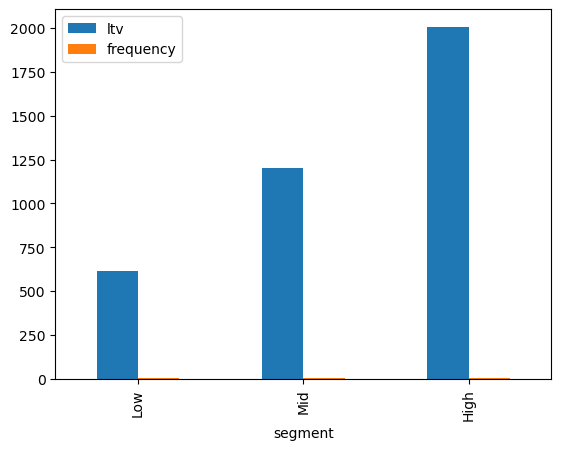

In [168]:
rfm.groupby('segment')[['ltv', 'frequency']].mean().plot(kind='bar')

Donors in the High segment have an average LTV of over 2000, which is 3.3 times higher than in the Low segment (~615). The core of the most loyal donors brings the bulk of the resources to the foundation. These are people who do not just give more at a time, but do it systematically (their frequency is 2.5 times higher). Losing even a small number of people from the High segment will have a critical impact on the budget. The number one priority is personal communication with them, for example, calls, reports, invitations to events).

In [169]:
#ROI campaigns

In [170]:
roi=df.groupby('campaign_id').agg({
    'amount':'sum',
    'cost':'first'
}).reset_index()

roi['roi']=roi['amount']/roi['cost']
roi=roi.merge(campaigns[['campaign_id', 'type']], on='campaign_id', how='left')
roi['profit']=roi['amount']-roi['cost']
roi.sort_values('roi', ascending=False)

,campaign_id,amount,cost,roi,type,profit
18,19,21472.0,1207,17.789561,Education,20265.0
10,11,26912.0,1552,17.340206,Education,25360.0
17,18,24428.0,1458,16.754458,Education,22970.0
19,20,29073.0,1899,15.309637,Health,27174.0
5,6,24915.0,1634,15.247858,Food,23281.0
16,17,28218.0,3430,8.226822,Health,24788.0
6,7,22836.0,2925,7.807179,Education,19911.0
7,8,23552.0,3056,7.706806,Education,20496.0
1,2,21014.0,2895,7.258722,Emergency,18119.0
14,15,27196.0,4389,6.196400,Education,22807.0


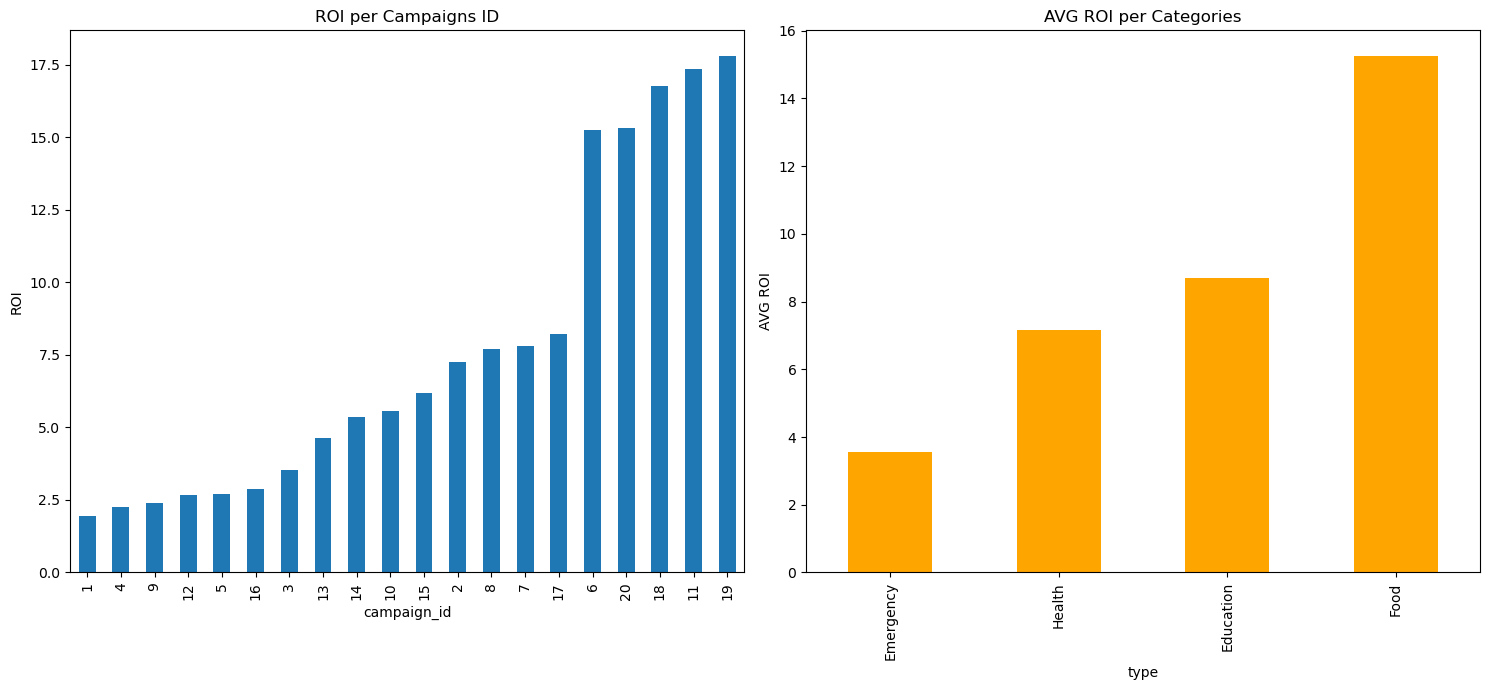

In [171]:
fig, (ax1, ax2)=plt.subplots(1, 2, figsize=(15,7))
roi.sort_values("roi").plot(
    x="campaign_id",
    y="roi",
    kind="bar",
    ax=ax1,
    legend=False
)
ax1.set_title('ROI per Campaigns ID')
ax1.set_ylabel('ROI')

roi.groupby('type')['roi'].mean().sort_values().plot(
    kind='bar',
    ax=ax2,
    color='orange'
)
ax2.set_title('AVG ROI per Categories')
ax2.set_ylabel('AVG ROI')

plt.tight_layout()
plt.show()

The best average ROI is in the Food category (15.3), but the highest individual indicators belong to three campaigns from the Education category (ID 19, 11, 18) with ROIs from 16.7 to 17.8.

While the Food segment is consistently effective for the foundation, it is individual Education projects that bring in the most donations and provide the highest level of return on each invested unit of expenditure. At the same time, the Emergency category works 4 times less efficiently than Food.

For quick fundraising, you should launch campaigns in the Food category, but to set fundraising records and attract large donations, you should use the mechanics that worked in the top Education projects

In [172]:
#Impact Analysis

In [173]:
impact_analys=df.groupby('campaign_id').agg({
    'amount':'sum',
    'people_helped':'first',
    'cost':'first'
})

impact_analys['cost_per_person']=impact_analys['cost']/impact_analys['people_helped']
impact_analys['revenue_per_person'] = impact_analys['amount'] / impact_analys['people_helped']
impact_analys['profit'] = impact_analys['amount'] - impact_analys['cost']

In [174]:
impact_analys.sort_values('cost_per_person').head()

,amount,people_helped,cost,cost_per_person,revenue_per_person,profit
campaign_id,,,,,,
6,24915.0,1751,1634,0.933181,14.229012,23281.0
18,24428.0,1154,1458,1.263432,21.168111,22970.0
14,26278.0,3438,4911,1.428447,7.643397,21367.0
17,28218.0,2343,3430,1.463935,12.043534,24788.0
11,26912.0,997,1552,1.556670,26.992979,25360.0


In [175]:
impact_analys.sort_values('revenue_per_person', ascending=False).head()

,amount,people_helped,cost,cost_per_person,revenue_per_person,profit
campaign_id,,,,,,
4,21417.0,106,9508,89.698113,202.047170,11909.0
8,23552.0,161,3056,18.981366,146.285714,20496.0
13,29611.0,807,6383,7.909542,36.692689,23228.0
3,25003.0,780,7090,9.089744,32.055128,17913.0
20,29073.0,958,1899,1.982255,30.347599,27174.0


In [176]:
impact_analys.sort_values('profit', ascending=False).head()

,amount,people_helped,cost,cost_per_person,revenue_per_person,profit
campaign_id,,,,,,
20,29073.0,958,1899,1.982255,30.347599,27174.0
11,26912.0,997,1552,1.556670,26.992979,25360.0
17,28218.0,2343,3430,1.463935,12.043534,24788.0
6,24915.0,1751,1634,0.933181,14.229012,23281.0
13,29611.0,807,6383,7.909542,36.692689,23228.0


In [177]:
good_campaigns=impact_analys[
    (impact_analys['cost_per_person']<impact_analys['cost_per_person'].median())&
    (impact_analys['profit']>impact_analys['profit'].median())
    ]
good_campaigns.head()

,amount,people_helped,cost,cost_per_person,revenue_per_person,profit
campaign_id,,,,,,
6,24915.0,1751,1634,0.933181,14.229012,23281.0
11,26912.0,997,1552,1.556670,26.992979,25360.0
14,26278.0,3438,4911,1.428447,7.643397,21367.0
15,27196.0,1891,4389,2.320994,14.381809,22807.0
17,28218.0,2343,3430,1.463935,12.043534,24788.0


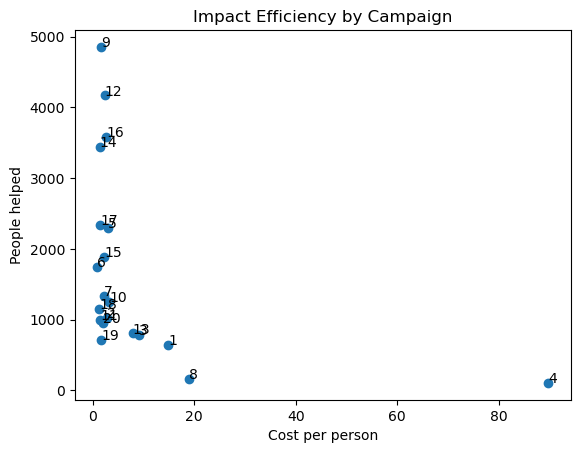

In [178]:
plt.scatter(
    impact_analys['cost_per_person'],
    impact_analys['people_helped']
)

for i, row in impact_analys.iterrows():
    plt.text(row['cost_per_person'], row['people_helped'], i)

plt.xlabel("Cost per person")
plt.ylabel("People helped")
plt.title("Impact Efficiency by Campaign")
plt.show()

There is a high concentration of projects in the low-cost segment (Cost per person < 10), where coverage ranges from 1,000 to 5,000 people. At the same time, a critical anomaly has been identified — ID 4, in which the cost of attracting assistance exceeds the average by ~40 times the minimum social effect.

The fund’s main operational efficiency is based on high-coverage programs with low average costs. The ID 4 campaign is a “point of inefficiency” where the costs of administration or implementation do not justify the final social result, which creates a risk of misuse of resources.

To maximize the fund’s social impact, it is necessary to introduce a maximum limit on the cost of assistance per person. Projects similar to ID 4 require immediate audit or restructuring, while the ID 9 campaign model should be scaled as the most balanced case according to the “costs - coverage” criteria.

In [179]:
#High Value Donors

In [180]:
high_value=rfm[rfm['segment']=='High']

high_value=high_value.merge(
    df[['donor_id', 'acquisition_channel', 'country']],
    on='donor_id',
    how='left')
high_value.head()

,donor_id,ltv,frequency,recency_days,segment,acquisition_channel,country
0,390,1679.0,7,1,High,Unknown,poland
1,390,1679.0,7,1,High,Unknown,poland
2,390,1679.0,7,1,High,Unknown,poland
3,390,1679.0,7,1,High,Unknown,poland
4,390,1679.0,7,1,High,Unknown,poland


In [181]:
high_value['acquisition_channel'].value_counts(normalize=True)

acquisition_channel
Unknown         0.221187
Referral        0.196924
Email           0.155979
Organic         0.153380
Facebook Ads    0.141031
Google Ads      0.131499
Name: proportion, dtype: float64

In [182]:
high_value['country'].value_counts()

country
ukraine    1864
germany     890
usa         732
poland      572
uk          558
Name: count, dtype: int64

In [183]:
high_value[['ltv', 'frequency', 'recency_days']].mean()

ltv             2096.456672
frequency          7.857019
recency_days      84.048310
dtype: float64

In [184]:
rfm.groupby('segment')[['ltv', 'frequency', 'recency_days']].mean()

C:\Users\nazar\AppData\Local\Temp\ipykernel_9320\1983236799.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,ltv,frequency,recency_days
segment,,,
Low,615.347962,2.978056,200.131661
Mid,1202.085537,4.916019,147.015552
High,2006.656151,7.280757,87.175079


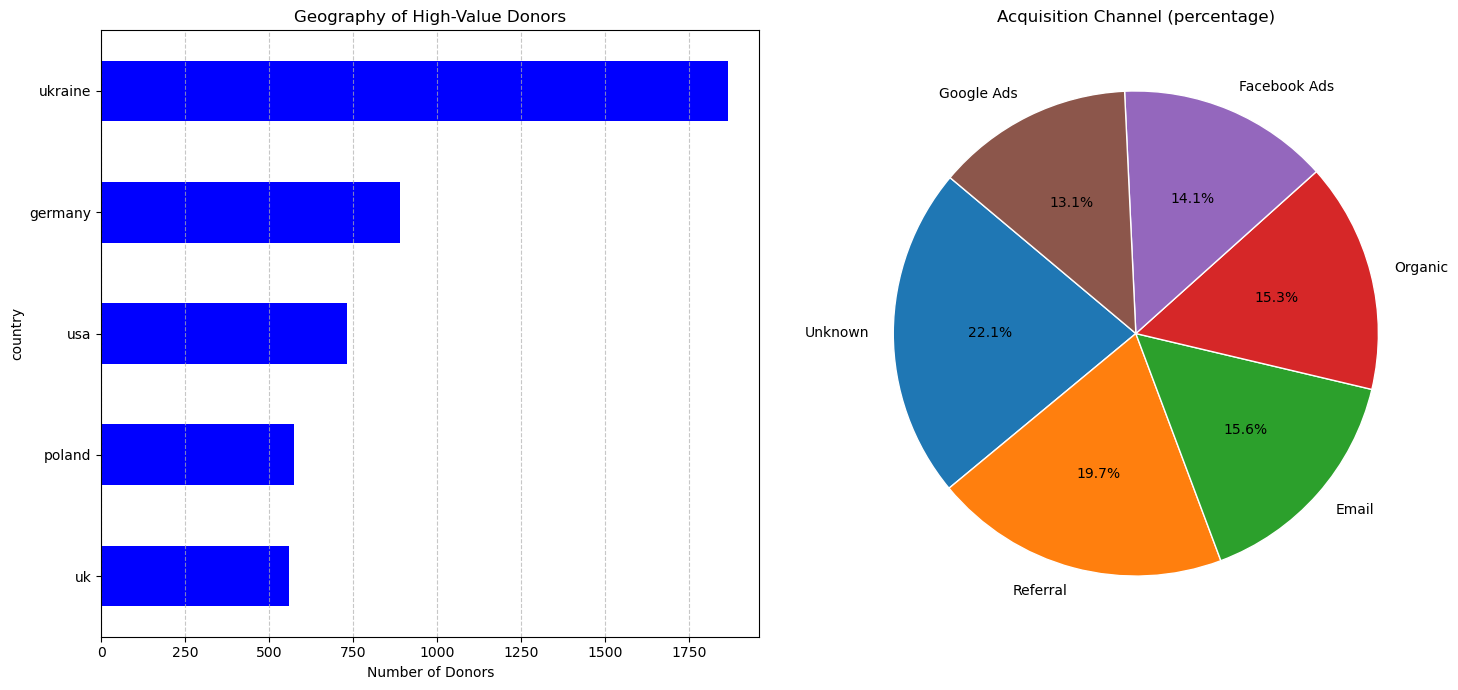

In [185]:
fig, (ax1, ax2)=plt.subplots(1, 2, figsize=(15,7))
high_value['country'].value_counts().sort_values().plot(
    kind="barh",
    ax=ax1,
    color='blue'
)
ax1.set_title('Geography of High-Value Donors')
ax1.set_xlabel('Number of Donors')
ax1.grid(axis='x', linestyle='--', alpha=0.7)

high_value['acquisition_channel'].value_counts(normalize=True).plot(
    kind='pie',
    ax=ax2,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white'}
)
ax2.set_title('Acquisition Channel (percentage)')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

A typical High-Value donor is a philanthropist from Ukraine (38% of the segment) who donates an average of 8 times a year with a total LTV of 2,096 units. At the same time, 19.7% of such donors are attracted through Referrals (recommendations), while the highest-quality Google Ads channel currently provides only 13.1% of this audience.

The foundation of the fund’s financial stability rests on local loyalty and reputational capital. High LTV with a relatively low share of paid channels (Google/Facebook Ads) indicates that the VIP segment is formed organically, but its growth is currently limited by the natural circle of communication of existing donors.

The fund has a successful loyal donor model, which now needs to be transferred to paid channels. Increasing investment in Google Ads will allow it to attract donors with the same high LTV as referrals, but in much larger volumes, going beyond the purely Ukrainian market and organic reach.

KEY INSIGHT:

RECOMMENDATIONS:

COCLUSION:

    The organization currently relies on unstable, one-time donations, with low retention and inefficient use of acquisition channels. Despite this, it has a strong foundation in the form of high-value, loyal donors and efficient campaign models.

    By shifting focus toward retention, scaling high-quality acquisition channels, and optimizing campaign efficiency, the NGO can transition from volatile fundraising to a stable, predictable, and scalable funding model.

A/B Test: Increasing Repeat Donations

BUSINESS PROBLEM:
    
    The NGO experiences extremely low retention: over 85% of donors make only one donation.
    This creates unstable revenue and high dependency on continuous acquisition.

HYPOTESIS:

    H0 (null): Email reminder does not affect repeat donation rate.
    H1 (alternative): Email reminder increases repeat donation rate.

EXPERIMENT DESIGN:

    Population: new donors (first-time donors)
    Control group: no follow-up communication
    Treatment group: email reminder sent 7 days after first donation

METRICS:

    Primary - Repeat donation rate (%)
    Secondary - Revenue per user (RPU); Average donation amount

In [186]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

In [187]:
#Data Preparation

In [188]:
df['date'] = pd.to_datetime(df['date'])

df['first_donation_date'] = df.groupby('donor_id')['date'].transform('min')

test_start_date = '2023-01-01'
new_donors_df = df[df['first_donation_date'] >= test_start_date].copy()

In [189]:
#A/B group

In [190]:
np.random.seed(42)

unique_donors = new_donors_df['donor_id'].unique()

group_assignment = pd.Series(
    np.random.choice(['control', 'treatment'], size=len(unique_donors)),
    index=unique_donors
)

new_donors_df['group'] = new_donors_df['donor_id'].map(group_assignment)

In [191]:
#Base Repeat(30 days)

In [192]:
new_donors_df['is_repeat_30d'] = (
    (new_donors_df['date'] > new_donors_df['first_donation_date']) &
    (new_donors_df['date'] <= new_donors_df['first_donation_date'] + pd.Timedelta(days=30))
)

ab_results = new_donors_df.groupby(['donor_id', 'group']).agg({
    'is_repeat_30d': 'max',
    'amount': 'sum'
}).reset_index()

In [193]:
#Add RFM

In [194]:
ab_results = ab_results.merge(
    rfm[['donor_id', 'segment']],
    on='donor_id',
    how='left'
)

In [195]:
#Simulated

In [196]:
np.random.seed(42)

def simulate_effect(row):
    base = row['is_repeat_30d']
    
    if row['group'] == 'control':
        return base

    if row['segment'] == 'High':
        if base:
            return True
        return np.random.rand() < 0.25
    
    elif row['segment'] == 'Mid':
        if base:
            return True
        return np.random.rand() < 0.15
    
    else:
        if base:
            return True
        return np.random.rand() < 0.08

ab_results['is_repeat_simulated'] = ab_results.apply(simulate_effect, axis=1)

In [197]:
#Z-test

In [198]:
stats = ab_results.groupby('group')['is_repeat_simulated'].agg(['sum', 'count'])

successes = stats['sum'].values
nobs = stats['count'].values

z_stat, p_val_conv = proportions_ztest(successes, nobs)

In [199]:
#T-test

In [200]:
rev_control = ab_results[ab_results['group'] == 'control']['amount']
rev_treatment = ab_results[ab_results['group'] == 'treatment']['amount']

t_stat, p_val_rev = ttest_ind(rev_treatment, rev_control, equal_var=False)

In [201]:
#Lift calculation

In [202]:
conversion = ab_results.groupby('group')['is_repeat_simulated'].mean()

control_rate = conversion['control']
treatment_rate = conversion['treatment']

lift = (treatment_rate - control_rate) / control_rate

In [203]:
#Segment Analysis

In [204]:
segment_effect = ab_results.groupby(['segment', 'group'])['is_repeat_simulated'].mean()

C:\Users\nazar\AppData\Local\Temp\ipykernel_9320\3709860543.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [205]:
#Result

In [206]:
print("=== Conversion Rates ===")
print(conversion)
print(f"\nLift: {lift:.2%}")

print("\n=== Statistical Tests ===")
print(f"Conversion P-value: {p_val_conv:.4f}")
print(f"Revenue P-value: {p_val_rev:.4f}")

print("\n=== Segment Effect ===")
print(segment_effect)

=== Conversion Rates ===
group
control      0.129843
treatment    0.318750
Name: is_repeat_simulated, dtype: float64

Lift: 145.49%

=== Statistical Tests ===
Conversion P-value: 0.0000
Revenue P-value: 0.3850

=== Segment Effect ===
segment  group    
Low      control      0.132686
         treatment    0.179331
Mid      control      0.091716
         treatment    0.347541
High     control      0.168831
         treatment    0.432515
Name: is_repeat_simulated, dtype: float64


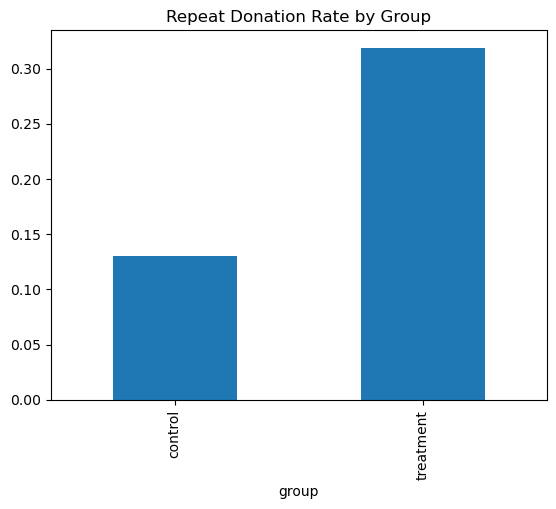

In [207]:
conversion.plot(kind="bar", title="Repeat Donation Rate by Group")
plt.show()

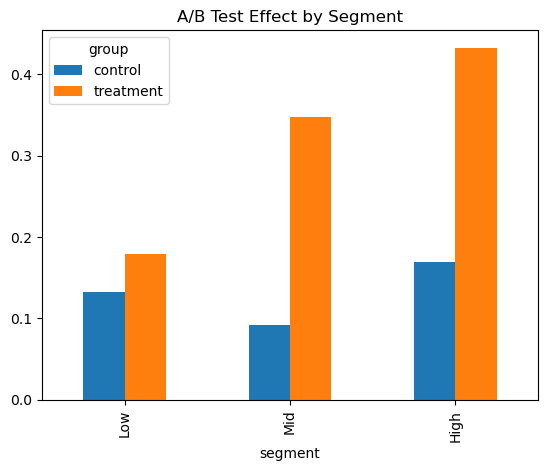

In [208]:
segment_effect.unstack().plot(kind="bar", title="A/B Test Effect by Segment")
plt.show()

TEST RESULTS:

    The treatment group shows a significant increase in repeat donation rate (31.9%) compared to the control group (13.0%), resulting in a lift of +145%.
    
    The difference is statistically significant (p < 0.001), indicating that the observed effect is unlikely due to random variation.

    Segment analysis reveals that the effect is strongest among Mid and High-value donors, where repeat rates increase up to 3–4 times.

BUSINESS INSIGHT:

    Email reminders significantly improve donor retention, particularly among more engaged donor segments.

    The strongest impact is observed in Mid and High-value donors, suggesting that these groups are more responsive to follow-up communication.

    This indicates that retention strategies should be segmented rather than applied uniformly.

RECOMMENDATION:

    Implement email reminders for all new donors
    
    Prioritize Mid and High-value segments for maximum impact
    
    Develop personalized communication strategies for high-value donors
    
    Further test optimization of timing and message content

LIMITATION:

    The experiment is simulated and assumes a predefined uplift effect. Real-world implementation may yield different results and should be validated through a live experiment.

In [209]:
#To next Visualization

In [210]:
donations.to_csv('donat_vis.csv', index=False)
donors.to_csv('donor_vis.csv', index=False)
campaigns.to_csv('camp_vis.csv', index=False)
impact.to_csv('impact_vis.csv', index=False)